# Working with images

## Images processing

In [89]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from skimage.feature import hog
from skimage.io import imread
from scipy.ndimage import convolve
from skimage.data import coins
from skimage.morphology import *
from skimage.measure import regionprops_table
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_olivetti_faces

In [28]:
imread('tiger.jpg')

array([[[223, 224, 226],
        [223, 224, 226],
        [223, 224, 226],
        ...,
        [225, 225, 227],
        [225, 225, 227],
        [225, 225, 227]],

       [[223, 224, 226],
        [223, 224, 226],
        [223, 224, 226],
        ...,
        [225, 225, 227],
        [225, 225, 227],
        [225, 225, 227]],

       [[224, 225, 227],
        [224, 225, 227],
        [224, 225, 227],
        ...,
        [226, 226, 228],
        [226, 226, 228],
        [226, 226, 228]],

       ...,

       [[199, 161, 124],
        [197, 159, 120],
        [198, 156, 118],
        ...,
        [ 80,  39,  19],
        [ 79,  38,  18],
        [ 79,  38,  18]],

       [[186, 147, 106],
        [185, 143, 101],
        [183, 140,  98],
        ...,
        [ 83,  42,  22],
        [ 82,  41,  21],
        [ 82,  41,  21]],

       [[175, 133,  91],
        [171, 130,  86],
        [169, 124,  82],
        ...,
        [ 84,  43,  23],
        [ 84,  43,  23],
        [ 83,  42,  22]]

In [29]:
type(imread('tiger.jpg'))

numpy.ndarray

In [30]:
tiger_image = imread('tiger.jpg')

In [31]:
tiger_image.shape

(600, 580, 3)

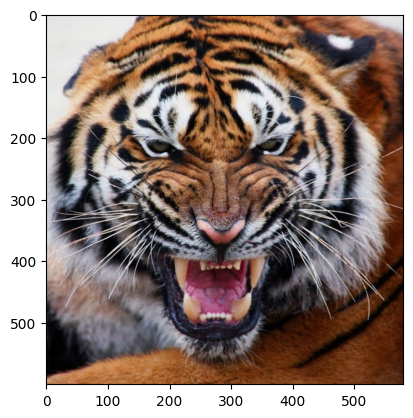

In [32]:
plt.imshow(tiger_image)

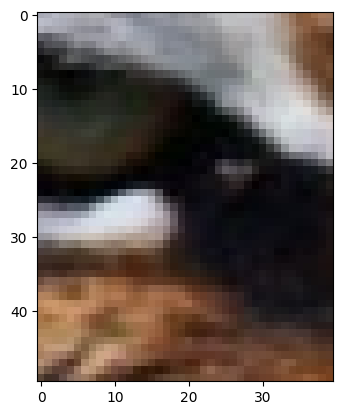

In [33]:
plt.imshow(tiger_image[200:250, 180:220])

In [34]:
tiger_image_eye = tiger_image[200:250, 180:220]

In [35]:
tiger_image_eye[:, :, 0].shape

(50, 40)

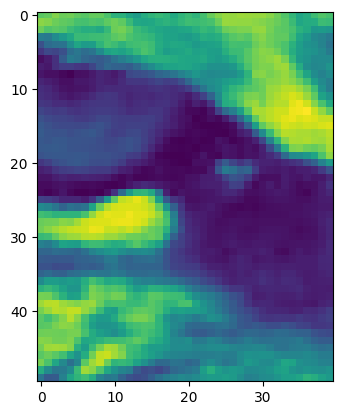

In [36]:
plt.imshow(tiger_image_eye[:, :, 0])

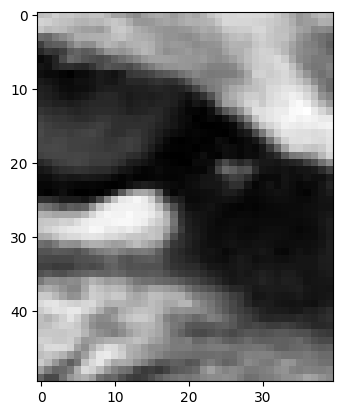

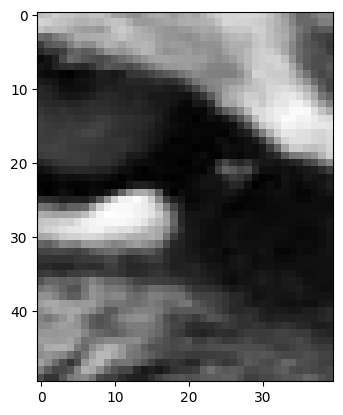

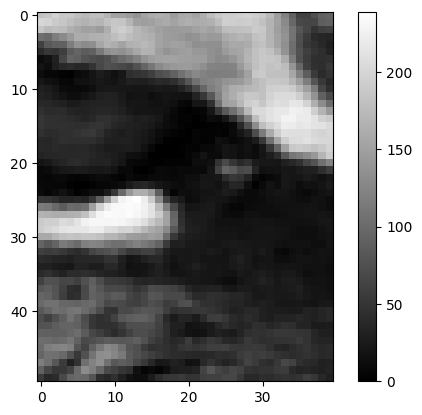

In [37]:
plt.imshow(tiger_image_eye[:, :, 0], cmap='gray')
plt.show()
plt.imshow(tiger_image_eye[:, :, 1], cmap='gray')
plt.show()
plt.imshow(tiger_image_eye[:, :, 2], cmap='gray')
plt.colorbar()

In [38]:
manul_image = imread('manul.jpg')

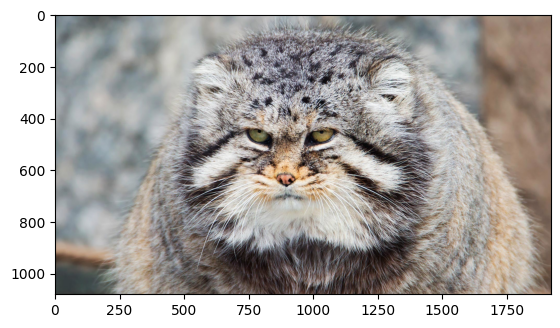

In [39]:
plt.imshow(manul_image)
plt.show()

In [68]:
sunset_image = imread('sunset.jpg')

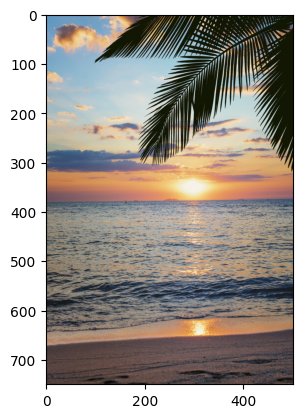

In [41]:
plt.imshow(sunset_image)
plt.show()  

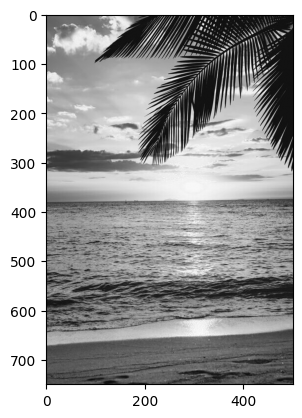

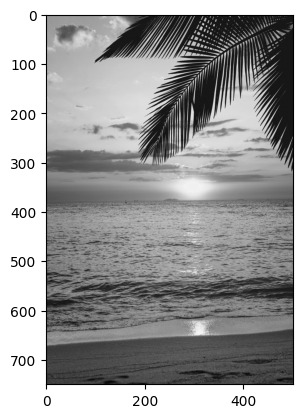

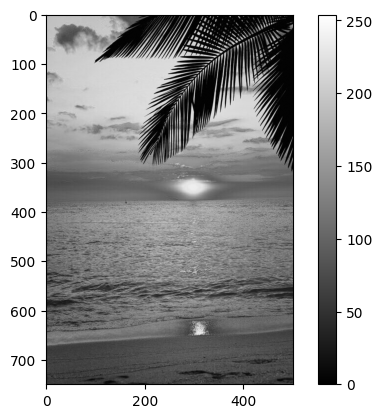

In [42]:
plt.imshow(sunset_image[:, :, 0], cmap='gray')
plt.show()  
plt.imshow(sunset_image[:, :, 1], cmap='gray')
plt.show()
plt.imshow(sunset_image[:, :, 2], cmap='gray')
plt.colorbar()

In [43]:
from astropy.io import fits

C:\Users\PC\AppData\Local\Temp\ipykernel_56516\2060046585.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(sunset_image[:, :, 0]), cmap='gray')


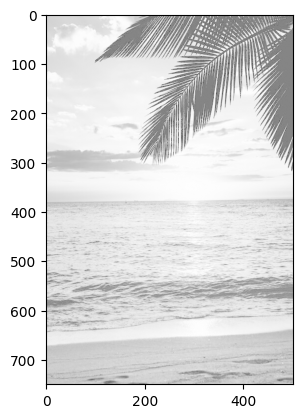

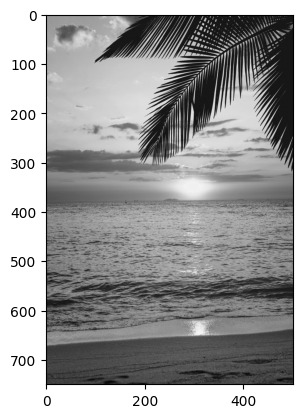

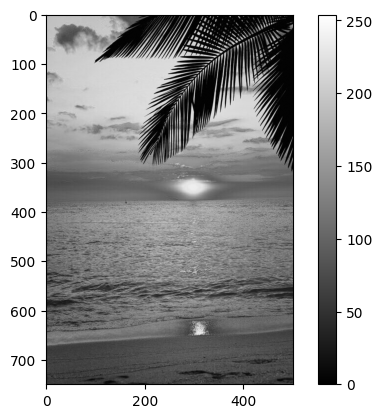

In [44]:
plt.imshow(np.log10(sunset_image[:, :, 0]), cmap='gray')
plt.show()  
plt.imshow(sunset_image[:, :, 1], cmap='gray')
plt.show()
plt.imshow(sunset_image[:, :, 2], cmap='gray')
plt.colorbar()

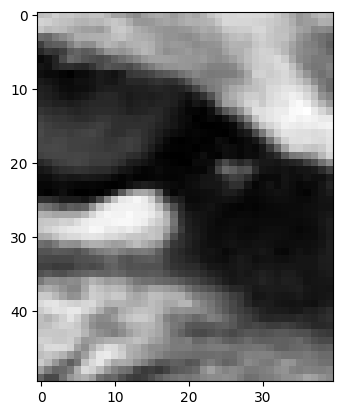

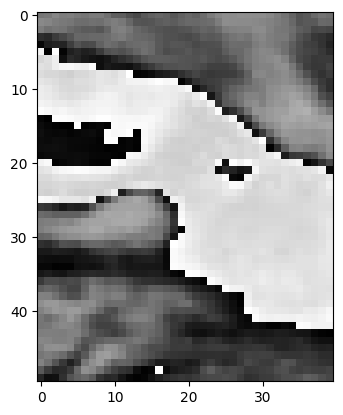

In [45]:
plt.imshow(tiger_image_eye[:, :, 0], cmap='gray')
plt.show()
plt.imshow(tiger_image_eye[:, :, 0] - 50, cmap='gray')
plt.show()

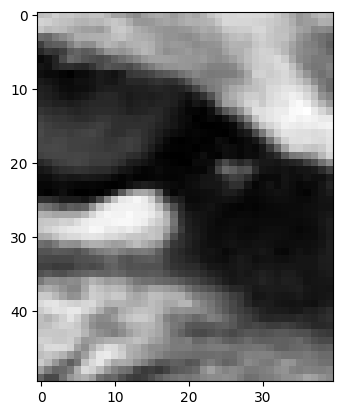

NameError: name 'darker' is not defined

In [46]:
plt.imshow(tiger_image_eye[:, :, 0], cmap='gray')
plt.show()
plt.imshow(darker, cmap='gray')
plt.show()

In [ ]:
tiger_image_eye[:, :, 0]

array([[168, 172, 184, ..., 156, 165, 160],
       [187, 183, 175, ..., 140, 155, 153],
       [175, 164, 168, ..., 120, 123, 119],
       ...,
       [180, 162, 134, ..., 107, 100,  99],
       [140, 109,  90, ..., 113, 112, 117],
       [ 88,  64,  66, ..., 141, 129, 121]], shape=(50, 40), dtype=uint8)

In [ ]:
x = np.array([1, 2, 3, 4, 5], dtype=np.uint8)

In [ ]:
x 

array([1, 2, 3, 4, 5], dtype=uint8)

In [ ]:
x + 50

array([51, 52, 53, 54, 55], dtype=uint8)

In [ ]:
tiger_image_eye[:, :, 0].astype(float) - 50

array([[118., 122., 134., ..., 106., 115., 110.],
       [137., 133., 125., ...,  90., 105., 103.],
       [125., 114., 118., ...,  70.,  73.,  69.],
       ...,
       [130., 112.,  84., ...,  57.,  50.,  49.],
       [ 90.,  59.,  40., ...,  63.,  62.,  67.],
       [ 38.,  14.,  16., ...,  91.,  79.,  71.]], shape=(50, 40))

In [ ]:
tiger_image_eye[:, :, 0].astype(float) + 50

array([[218., 222., 234., ..., 206., 215., 210.],
       [237., 233., 225., ..., 190., 205., 203.],
       [225., 214., 218., ..., 170., 173., 169.],
       ...,
       [230., 212., 184., ..., 157., 150., 149.],
       [190., 159., 140., ..., 163., 162., 167.],
       [138., 114., 116., ..., 191., 179., 171.]], shape=(50, 40))

In [ ]:
darker = tiger_image_eye[:, :, 0].astype(float) - 50

In [ ]:
darker.min(), darker.max()

(np.float64(-50.0), np.float64(176.0))

In [ ]:
darker[darker < 0] = 0
darker[darker > 255] = 255

In [ ]:
np.clip(darker, 0, 255)

array([[118., 122., 134., ..., 106., 115., 110.],
       [137., 133., 125., ...,  90., 105., 103.],
       [125., 114., 118., ...,  70.,  73.,  69.],
       ...,
       [130., 112.,  84., ...,  57.,  50.,  49.],
       [ 90.,  59.,  40., ...,  63.,  62.,  67.],
       [ 38.,  14.,  16., ...,  91.,  79.,  71.]], shape=(50, 40))

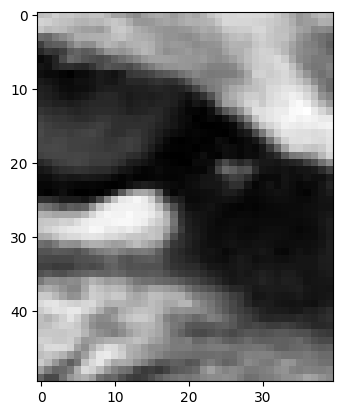

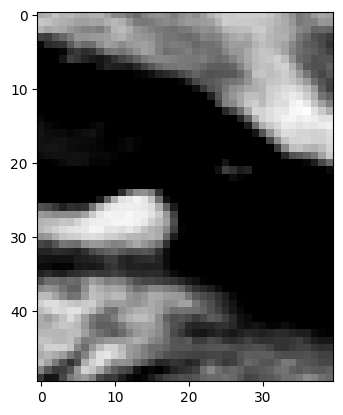

In [ ]:
plt.imshow(tiger_image_eye[:, :, 0], cmap='gray')
plt.show()
result = tiger_image_eye[:, :, 0].astype(float)
result-= 50
result = np.clip(result, 0, 255)
plt.imshow(result, cmap='gray')
plt.show()  

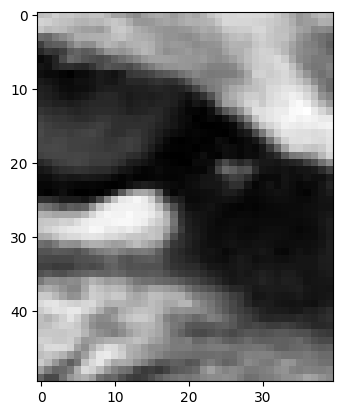

C:\Users\PC\AppData\Local\Temp\ipykernel_47480\3980627479.py:4: RuntimeWarning: divide by zero encountered in log10
  result = np.log10(result)


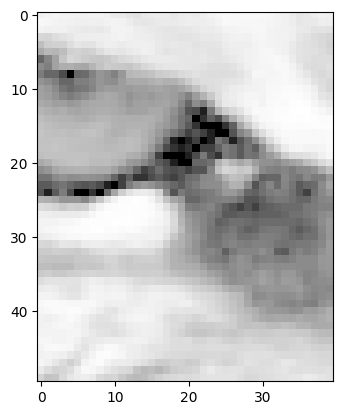

In [ ]:
plt.imshow(tiger_image_eye[:, :, 0], cmap='gray')
plt.show()
result = tiger_image_eye[:, :, 0].astype(float)
result = np.log10(result)
result = np.clip(result, 0, 255)
plt.imshow(result, cmap='gray')
plt.show()  

(array([[ 7.,  7., 10.,  3.,  4.,  0.,  4., 12.,  3.,  0.],
        [ 7.,  7., 10.,  3.,  4.,  1.,  4.,  8.,  6.,  0.],
        [ 6.,  7., 11.,  5.,  2.,  2.,  2., 10.,  5.,  0.],
        [ 6.,  6., 11.,  4.,  3.,  4.,  3.,  5.,  8.,  0.],
        [ 7.,  6.,  8.,  5.,  3.,  7.,  2.,  3.,  7.,  2.],
        [ 7.,  5.,  8.,  6.,  1.,  6.,  6.,  5.,  4.,  2.],
        [ 7.,  6.,  6.,  7.,  0.,  3.,  9.,  6.,  4.,  2.],
        [ 6.,  6.,  8.,  3.,  2.,  4.,  7.,  6.,  6.,  2.],
        [ 3.,  7., 10.,  3.,  3.,  3.,  7.,  8.,  1.,  5.],
        [ 5.,  5.,  7.,  5.,  1.,  8.,  5.,  7.,  3.,  4.],
        [ 4.,  9.,  4.,  3.,  4.,  5.,  7.,  7.,  3.,  4.],
        [ 3., 10.,  3.,  6.,  3.,  3.,  7.,  8.,  3.,  4.],
        [ 3.,  9.,  6.,  3.,  3.,  3., 12.,  6.,  0.,  5.],
        [ 3.,  9.,  6.,  4.,  2.,  5., 10.,  6.,  1.,  4.],
        [ 3., 12.,  3.,  3.,  3.,  4.,  9.,  8.,  1.,  4.],
        [ 4., 11.,  2.,  4.,  4.,  3., 11.,  7.,  3.,  1.],
        [ 7.,  7.,  2.,  8.,  1.,  6., 1

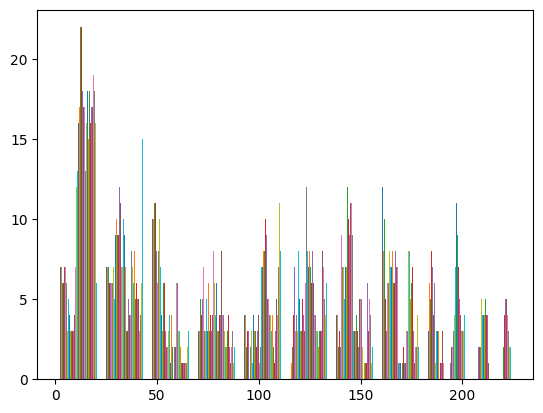

In [ ]:
plt.hist(tiger_image_eye[:, :, 0])

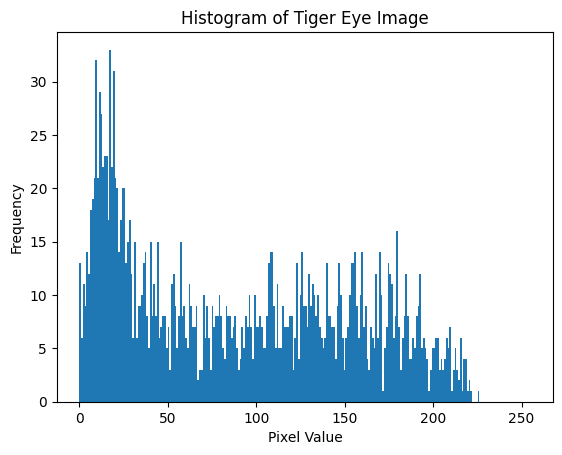

In [ ]:
plt.hist(tiger_image_eye[:, :, 0].ravel(), bins=256, range=(0, 255))
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram of Tiger Eye Image')
plt.show()

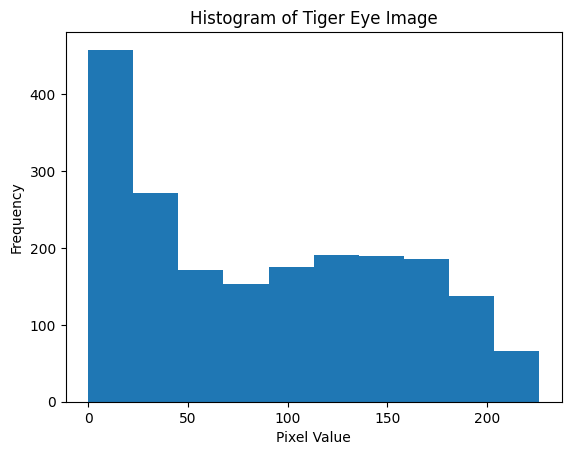

In [ ]:
plt.hist(tiger_image_eye[:, :, 0].ravel())
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram of Tiger Eye Image')
plt.show()

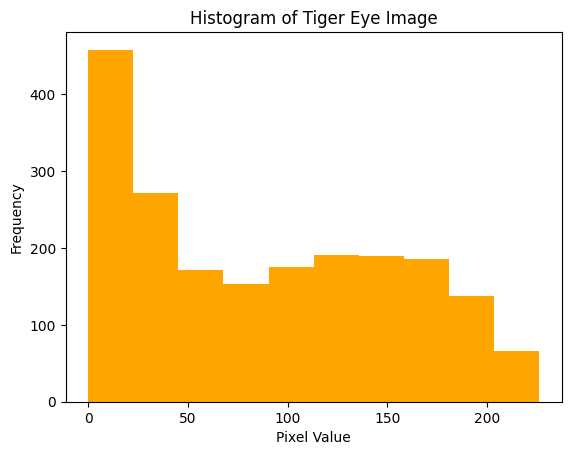

In [ ]:
plt.hist(tiger_image_eye[:, :, 0].ravel(), color='orange')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram of Tiger Eye Image')
plt.show()

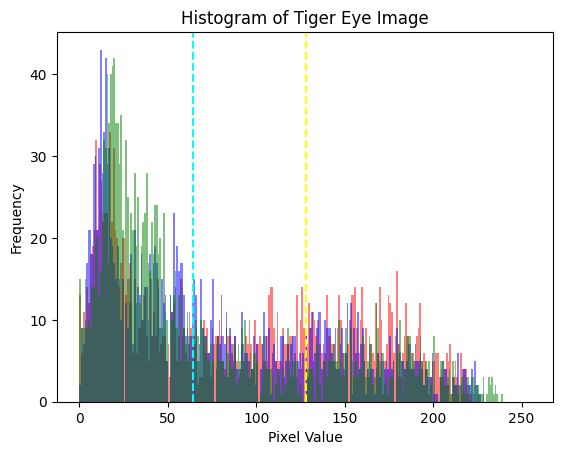

In [ ]:
plt.hist(tiger_image_eye[:, :, 0].ravel(), bins=256, range=(0, 255), color='red', alpha=0.5)
plt.hist(tiger_image_eye[:, :, 1].ravel(), bins=265, range=(0, 255), color='blue', alpha=0.5)
plt.hist(tiger_image_eye[:, :, 2].ravel(), bins=265, range=(0, 255), color='green', alpha=0.5)
plt.axvline(x=128, color='yellow', linestyle='--')
plt.axvline(x=64, color='cyan', linestyle='--')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram of Tiger Eye Image')
plt.show()

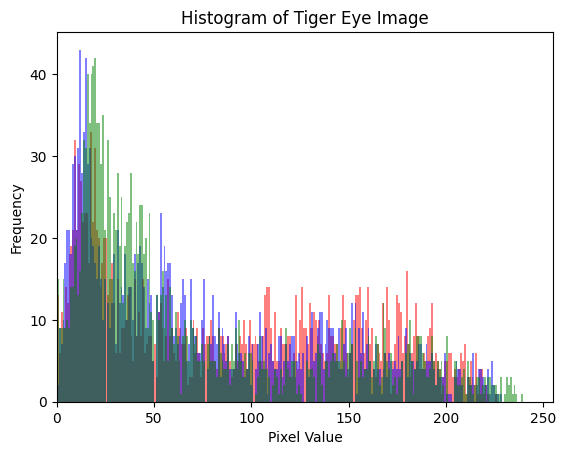

In [ ]:
plt.hist(tiger_image_eye[:, :, 0].ravel(), bins=256, range=(0, 255), color='red', alpha=0.5)
plt.hist(tiger_image_eye[:, :, 1].ravel(), bins=265, range=(0, 255), color='blue', alpha=0.5)
plt.hist(tiger_image_eye[:, :, 2].ravel(), bins=265, range=(0, 255), color='green', alpha=0.5)
plt.xlim(0, 255)
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram of Tiger Eye Image')
plt.show()

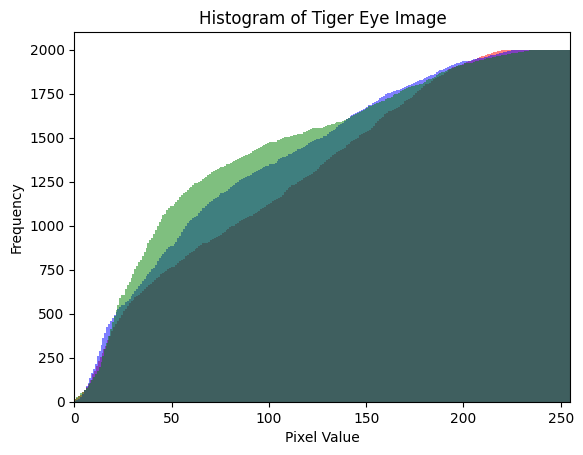

In [ ]:
plt.hist(tiger_image_eye[:, :, 0].ravel(), bins=256, range=(0, 255), color='red', alpha=0.5, cumulative=True)
plt.hist(tiger_image_eye[:, :, 1].ravel(), bins=265, range=(0, 255), color='blue', alpha=0.5, cumulative=True)
plt.hist(tiger_image_eye[:, :, 2].ravel(), bins=265, range=(0, 255), color='green', alpha=0.5, cumulative=True)
plt.xlim(0, 255)
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram of Tiger Eye Image')
plt.show()

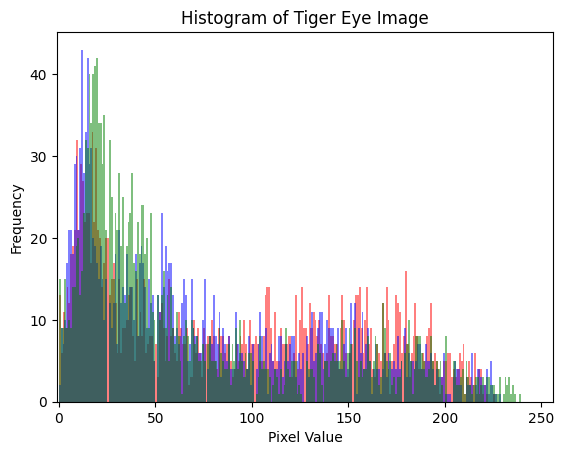

In [ ]:
plt.hist(tiger_image_eye[:, :, 0].ravel(), bins=256, range=(0, 255), color='red', alpha=0.5)
plt.hist(tiger_image_eye[:, :, 1].ravel(), bins=265, range=(0, 255), color='blue', alpha=0.5)
plt.hist(tiger_image_eye[:, :, 2].ravel(), bins=265, range=(0, 255), color='green', alpha=0.5)
plt.xlim(-1, 256)
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram of Tiger Eye Image')
plt.show()

## Converting to grayscale

In [52]:
r = tiger_image_eye[:, :, 0].astype(int)
b = tiger_image_eye[:, :, 1].astype(int)
g = tiger_image_eye[:, :, 2].astype(int)

In [53]:
(r + b + g)/ 3

array([[173.33333333, 177.33333333, 189.33333333, ..., 114.33333333,
        126.        , 124.66666667],
       [192.33333333, 188.33333333, 180.33333333, ..., 100.33333333,
        118.66666667, 120.        ],
       [178.33333333, 167.33333333, 171.33333333, ...,  81.66666667,
         88.        ,  87.66666667],
       ...,
       [147.33333333, 130.66666667, 104.66666667, ...,  70.33333333,
         63.33333333,  62.66666667],
       [115.        ,  86.        ,  68.33333333, ...,  69.66666667,
         67.66666667,  72.66666667],
       [ 70.66666667,  49.33333333,  51.33333333, ...,  93.        ,
         80.        ,  72.        ]], shape=(50, 40))

In [ ]:
tiger_image_eye.mean(axis=0).shape

(40, 3)

In [ ]:
tiger_image_eye.shape

(50, 40, 3)

In [ ]:
tiger_image_eye.mean(axis=2)

array([[173.33333333, 177.33333333, 189.33333333, ..., 114.33333333,
        126.        , 124.66666667],
       [192.33333333, 188.33333333, 180.33333333, ..., 100.33333333,
        118.66666667, 120.        ],
       [178.33333333, 167.33333333, 171.33333333, ...,  81.66666667,
         88.        ,  87.66666667],
       ...,
       [147.33333333, 130.66666667, 104.66666667, ...,  70.33333333,
         63.33333333,  62.66666667],
       [115.        ,  86.        ,  68.33333333, ...,  69.66666667,
         67.66666667,  72.66666667],
       [ 70.66666667,  49.33333333,  51.33333333, ...,  93.        ,
         80.        ,  72.        ]], shape=(50, 40))

In [ ]:
tiger_image_eye_gs = tiger_image_eye.mean(axis=2)

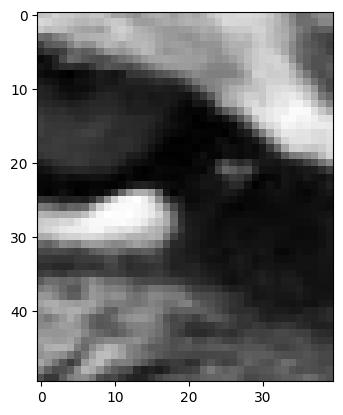

In [ ]:
plt.imshow(tiger_image_eye_gs, cmap='gray')
plt.show()

In [54]:
tiger_image_eye_grey = 0.299 * r + 0.587 * g + 0.114 * b

In [55]:
tiger_image_eye_gs

NameError: name 'tiger_image_eye_gs' is not defined

In [56]:
tiger_image_eye_grey

array([[176.446, 180.446, 192.446, ..., 104.383, 117.133, 116.698],
       [195.446, 191.446, 183.446, ...,  91.432, 110.883, 112.861],
       [180.87 , 169.87 , 173.87 , ...,  73.307,  80.285,  80.85 ],
       ...,
       [139.502, 123.85 ,  99.372, ...,  61.823,  54.823,  54.883],
       [108.746,  80.795,  64.616, ...,  59.867,  58.052,  63.052],
       [ 66.463,  46.213,  49.159, ...,  82.014,  69.199,  61.199]],
      shape=(50, 40))

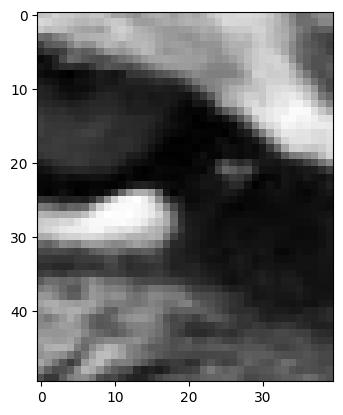

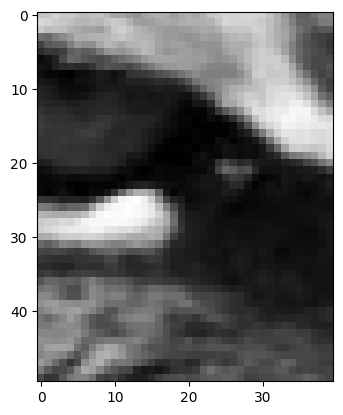

In [ ]:
plt.imshow(tiger_image_eye_gs, cmap='gray')
plt.show()
plt.imshow(tiger_image_eye_grey, cmap='gray')
plt.show()

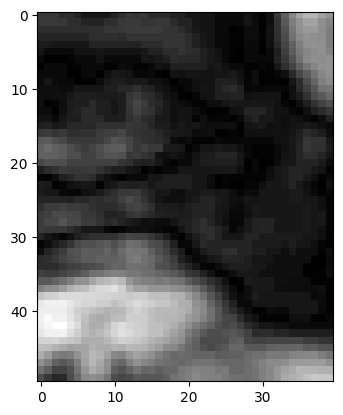

In [ ]:
plt.imshow(np.abs(tiger_image_eye_grey - tiger_image_eye_gs), cmap='gray')
plt.show()

In [ ]:
conv_filter = np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]])
(convolve(tiger_image_eye_gs, conv_filter) == convolve(tiger_image_eye_grey, conv_filter)).all()

np.False_

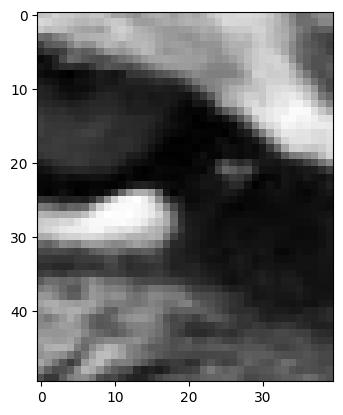

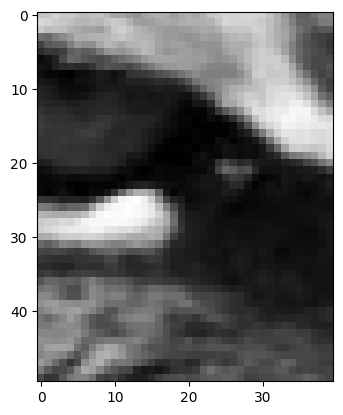

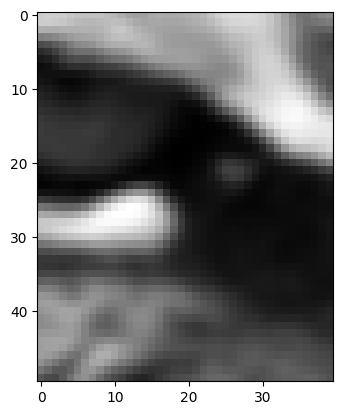

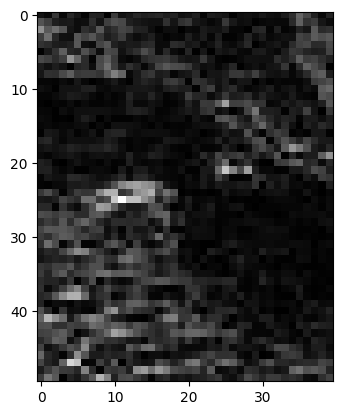

In [ ]:
conv_filter = np.array([[1, 1, 1], [1, 1, 1], [1 , 1, 1]])/9
conv_result = convolve(tiger_image_eye_gs, conv_filter)
plt.imshow(tiger_image_eye_gs, cmap='gray')
plt.show()
plt.imshow(tiger_image_eye_grey, cmap='gray')
plt.show()
plt.imshow(conv_result, cmap='gray')
plt.show()
plt.imshow(np.abs(conv_result - tiger_image_eye_grey), cmap='gray')
plt.show()

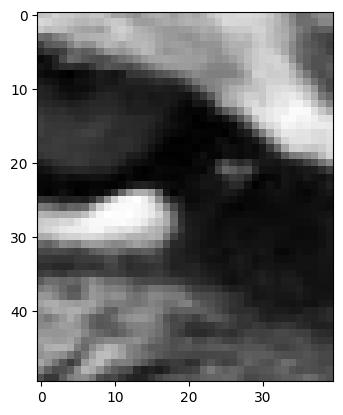

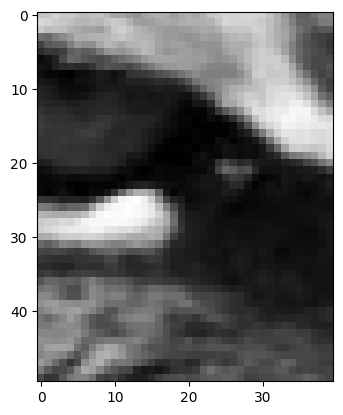

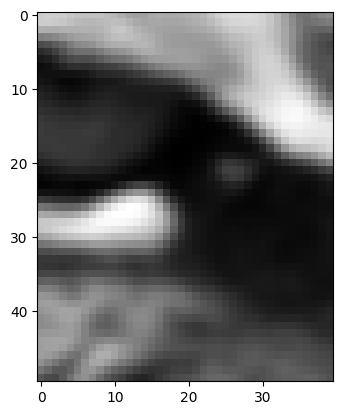

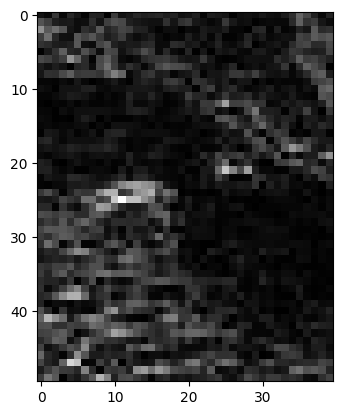

In [ ]:
size = 5
conv_filter = np.ones((size, size))/(size*size)
plt.imshow(tiger_image_eye_gs, cmap='gray')
plt.show()
plt.imshow(tiger_image_eye_grey, cmap='gray')
plt.show()
plt.imshow(conv_result, cmap='gray')
plt.show()
plt.imshow(np.abs(conv_result - tiger_image_eye_grey), cmap='gray')
plt.show()

In [ ]:
(conv_result/81).min(), (conv_result/81).max()  

(np.float64(0.030178326474622767), np.float64(2.7617741197988113))

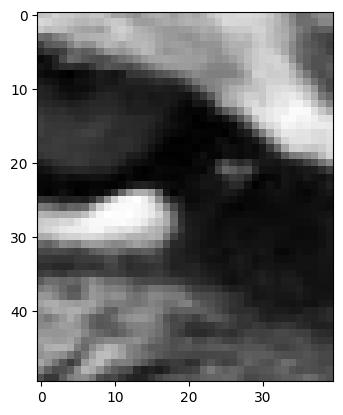

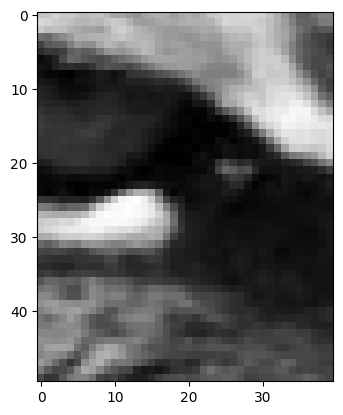

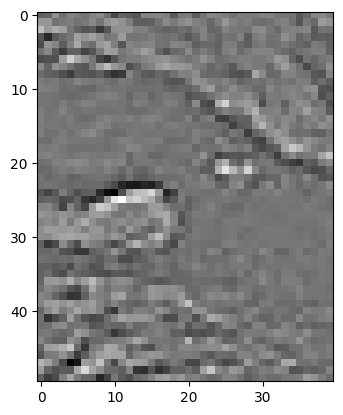

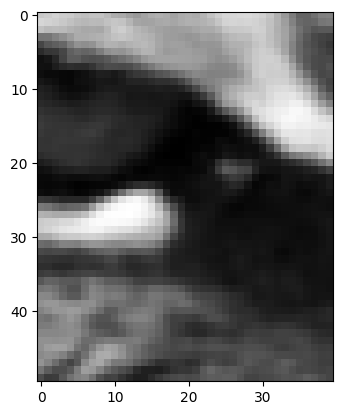

In [ ]:
conv_filter = np.array([[0, -1, 0], [-1, 4, -1], [0 ,-1, 0]])/9
conv_result = convolve(tiger_image_eye_gs, conv_filter)
conv_result = np.clip(conv_result, -100, 100)
plt.imshow(tiger_image_eye_gs, cmap='gray')
plt.show()
plt.imshow(tiger_image_eye_grey, cmap='gray')
plt.show()
plt.imshow(conv_result, cmap='gray')
plt.show()
plt.imshow(np.abs(conv_result - tiger_image_eye_grey), cmap='gray')
plt.show()

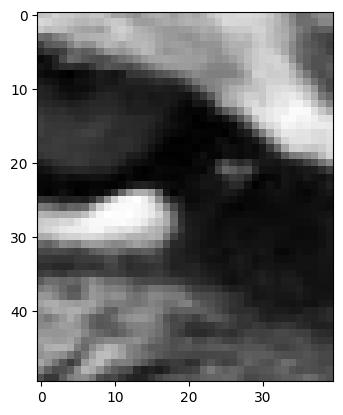

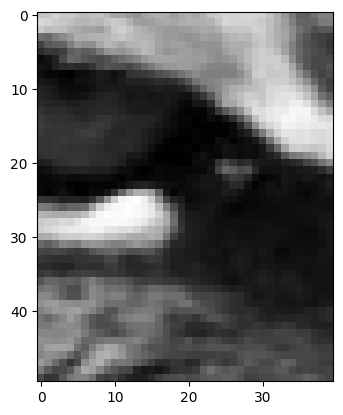

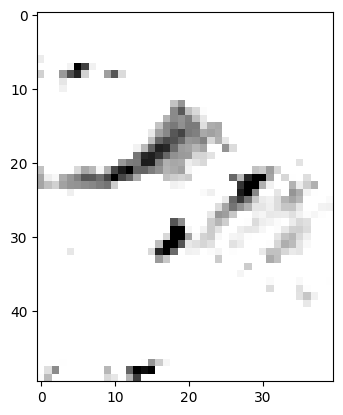

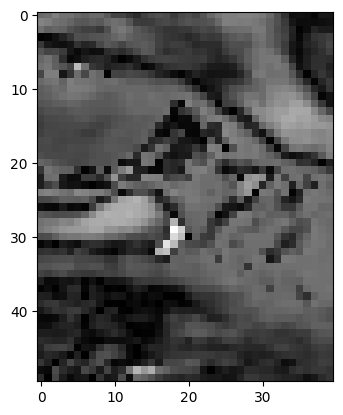

In [ ]:
conv_filter = np.array([[0, 1, 3], [5, -2, 2], [3 ,1, -7]])
conv_result = convolve(tiger_image_eye_gs, conv_filter)
conv_result = np.clip(conv_result, -100, 100)
plt.imshow(tiger_image_eye_gs, cmap='gray')
plt.show()
plt.imshow(tiger_image_eye_grey, cmap='gray')
plt.show()
plt.imshow(conv_result, cmap='gray')
plt.show()
plt.imshow(np.abs(conv_result - tiger_image_eye_grey), cmap='gray')
plt.show()

In [ ]:
conv_result.min(), conv_result.max()

(np.float64(-100.0), np.float64(100.0))

In [ ]:
hog(tiger_image_eye_grey, orientations=4)

array([0.03816749, 0.32543956, 0.32543956, 0.12351092, 0.07718796,
       0.13002201, 0.32543956, 0.09373768, 0.09399796, 0.07457409,
       0.27894557, 0.03108184, 0.0124077 , 0.11181721, 0.24748252,
       0.02832065, 0.03652883, 0.08954322, 0.29902473, 0.03362031,
       0.07462307, 0.05252891, 0.32543956, 0.08211199, 0.0319204 ,
       0.09626602, 0.2348255 , 0.00474802, 0.14983967, 0.32543956,
       0.15907121, 0.00927586, 0.12504991, 0.05628646, 0.08282937,
       0.0165737 , 0.06758944, 0.11385344, 0.3128936 , 0.08208116,
       0.08230907, 0.06530061, 0.24425797, 0.02721673, 0.11396339,
       0.02705774, 0.18253308, 0.18591091, 0.03198638, 0.07840829,
       0.26184023, 0.02943954, 0.0653435 , 0.04599681, 0.3128936 ,
       0.07190115, 0.10085024, 0.13480559, 0.3128936 , 0.3128936 ,
       0.13120672, 0.3128936 , 0.13929029, 0.00812238, 0.10949963,
       0.0492871 , 0.07252932, 0.01451271, 0.08740316, 0.21116705,
       0.3128936 , 0.09986905, 0.06581987, 0.05221876, 0.19532

In [ ]:
hog(tiger_image_eye_grey,pixels_per_cell=(8, 8), orientations=4)

array([0.03816749, 0.32543956, 0.32543956, 0.12351092, 0.07718796,
       0.13002201, 0.32543956, 0.09373768, 0.09399796, 0.07457409,
       0.27894557, 0.03108184, 0.0124077 , 0.11181721, 0.24748252,
       0.02832065, 0.03652883, 0.08954322, 0.29902473, 0.03362031,
       0.07462307, 0.05252891, 0.32543956, 0.08211199, 0.0319204 ,
       0.09626602, 0.2348255 , 0.00474802, 0.14983967, 0.32543956,
       0.15907121, 0.00927586, 0.12504991, 0.05628646, 0.08282937,
       0.0165737 , 0.06758944, 0.11385344, 0.3128936 , 0.08208116,
       0.08230907, 0.06530061, 0.24425797, 0.02721673, 0.11396339,
       0.02705774, 0.18253308, 0.18591091, 0.03198638, 0.07840829,
       0.26184023, 0.02943954, 0.0653435 , 0.04599681, 0.3128936 ,
       0.07190115, 0.10085024, 0.13480559, 0.3128936 , 0.3128936 ,
       0.13120672, 0.3128936 , 0.13929029, 0.00812238, 0.10949963,
       0.0492871 , 0.07252932, 0.01451271, 0.08740316, 0.21116705,
       0.3128936 , 0.09986905, 0.06581987, 0.05221876, 0.19532

In [ ]:
corrected_hog = hog(tiger_image_eye_grey, orientations=8).shape

In [ ]:
hog(r,pixels_per_cell=(8, 8), orientations=4)

array([0.03376474, 0.31515995, 0.31515995, 0.11601679, 0.08675208,
       0.09734207, 0.31515995, 0.09413268, 0.06545852, 0.06477988,
       0.2991841 , 0.03710067, 0.01503446, 0.12390174, 0.23819276,
       0.04486278, 0.03675524, 0.09871257, 0.29314847, 0.02370127,
       0.11121876, 0.06367278, 0.31515995, 0.08793694, 0.00714563,
       0.1352523 , 0.30835818, 0.01348071, 0.12180485, 0.31515995,
       0.08905936, 0.01495341, 0.14501137, 0.06420334, 0.06923217,
       0.0303036 , 0.07780971, 0.08730809, 0.30589794, 0.08442952,
       0.05871108, 0.0581024 , 0.26834432, 0.03327635, 0.07973546,
       0.0173619 , 0.21150278, 0.17442795, 0.03296652, 0.08853732,
       0.26293084, 0.02125815, 0.09975437, 0.05710941, 0.30589794,
       0.07887243, 0.11004882, 0.12223396, 0.30589794, 0.30589794,
       0.10924925, 0.30589794, 0.07987916, 0.01341202, 0.13006365,
       0.05758529, 0.06209574, 0.02717992, 0.07621105, 0.23304794,
       0.30589794, 0.1660081 , 0.05076842, 0.05024208, 0.23204

In [ ]:
hog(g,pixels_per_cell=(8, 8), orientations=4)

array([0.03223354, 0.33170211, 0.33170211, 0.11486833, 0.06036629,
       0.1476586 , 0.33170211, 0.10023789, 0.0956245 , 0.08014842,
       0.26228892, 0.04469039, 0.0148804 , 0.10954146, 0.23570902,
       0.02995374, 0.0339174 , 0.09711841, 0.29845041, 0.04605754,
       0.06426157, 0.0450028 , 0.33170211, 0.09409523, 0.02588111,
       0.09174931, 0.21493115, 0.01252498, 0.12979898, 0.33170211,
       0.17798571, 0.01141638, 0.10701806, 0.07993508, 0.07806178,
       0.01686869, 0.05250321, 0.12842516, 0.31413795, 0.08718129,
       0.08316882, 0.06970859, 0.22812417, 0.03886919, 0.12752193,
       0.02259435, 0.18427861, 0.18939687, 0.02949945, 0.08446814,
       0.25957541, 0.04005826, 0.05589111, 0.03914091, 0.31413795,
       0.08183875, 0.11902744, 0.13790373, 0.31413795, 0.31413795,
       0.11289186, 0.31077873, 0.15480198, 0.00992933, 0.0930783 ,
       0.06952305, 0.06789375, 0.01467144, 0.10595584, 0.17265417,
       0.31413795, 0.11632251, 0.06514061, 0.05459811, 0.17867

In [ ]:
hog(b,pixels_per_cell=(8, 8), orientations=4)

array([0.0378802 , 0.31793441, 0.31793441, 0.11991513, 0.08714619,
       0.11154269, 0.31793441, 0.1046934 , 0.07926011, 0.05148934,
       0.30536301, 0.04003096, 0.01825979, 0.13805429, 0.24013422,
       0.02475216, 0.04587893, 0.07078763, 0.27035075, 0.04748465,
       0.06617489, 0.04679874, 0.31793441, 0.10890679, 0.02337047,
       0.09831668, 0.29947435, 0.0095137 , 0.12512295, 0.31793441,
       0.16919295, 0.01358992, 0.11542689, 0.05931994, 0.05852753,
       0.02670286, 0.07763803, 0.09937273, 0.30662995, 0.09327073,
       0.07061237, 0.04587155, 0.27204612, 0.03566335, 0.10938549,
       0.02934136, 0.20555846, 0.17087484, 0.04087327, 0.06306429,
       0.2408539 , 0.0423038 , 0.05895482, 0.04169272, 0.30662995,
       0.09702442, 0.11099367, 0.11943947, 0.30662995, 0.30662995,
       0.11147131, 0.30662995, 0.15073301, 0.01210718, 0.10283314,
       0.05284778, 0.05214184, 0.02378942, 0.08173969, 0.246921  ,
       0.30662995, 0.13549554, 0.05574816, 0.03621539, 0.21477

In [ ]:
r.shape

(50, 40)

In [ ]:
body_r_hog =hog(tiger_image[50:550, 400:500, 0], pixels_per_cell=(8, 8), orientations=4).shape

In [ ]:
np.linalg.norm(body_r_hog)

np.float64(21600.0)

In [ ]:
np.linalg.norm(body_r_hog - corrected_hog)

TypeError: unsupported operand type(s) for -: 'tuple' and 'tuple'

## Morphology and measurements

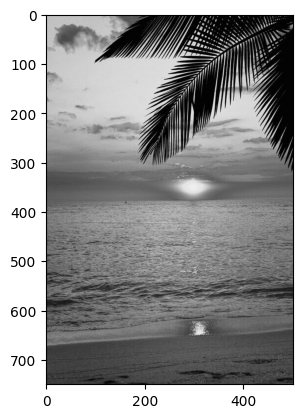

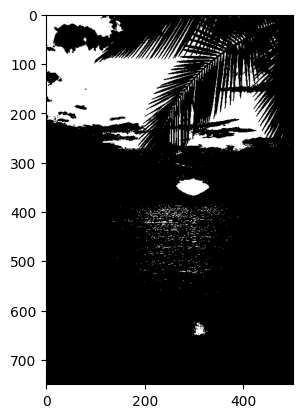

In [70]:
plt.imshow(sunset_image[:, :, 2], cmap='gray')
plt.show()

threshold = 180
result = sunset_image[:, :, 2].copy()
result[result < threshold] = 0
result[result >= threshold] = 255
plt.imshow(result, cmap='gray')
plt.show()



In [ ]:
coins_image = coins()

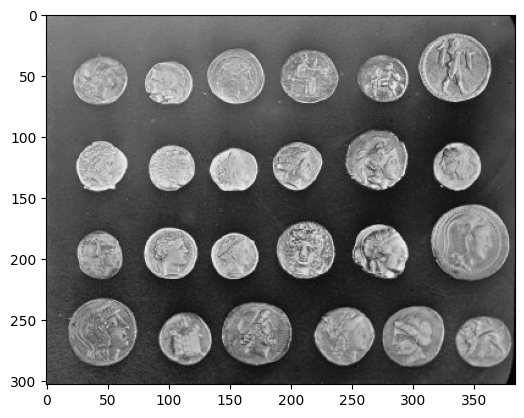

In [ ]:
plt.imshow(coins_image, cmap='gray')
plt.show()

In [ ]:
from skimage.filters import threshold_otsu

In [ ]:
threshold_otsu(coins_image)

np.int64(107)

In [ ]:
threshold_result = threshold_otsu(coins_image)

In [ ]:
coins_threshold = coins_image.copy()
coins_threshold[coins_threshold < threshold_result] = 0
coins_threshold[coins_threshold >= threshold_result] = 1

In [ ]:
coins_threshold

array([[0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(303, 384), dtype=uint8)

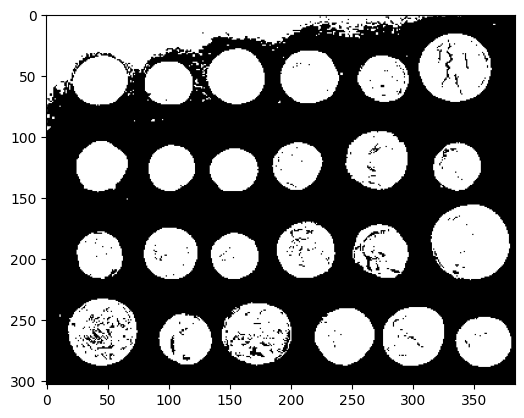

In [ ]:
plt.imshow(coins_threshold, cmap='grey')
plt.show()

In [ ]:
remove_small_holes(coins_threshold)

c:\Обучения\Data Science\Working with Images\.venv\Lib\site-packages\skimage\_shared\utils.py:386: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  return func(*args, **kwargs)


array([[ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(303, 384))

In [ ]:
result = remove_small_holes(coins_threshold).astype(int)

c:\Обучения\Data Science\Working with Images\.venv\Lib\site-packages\skimage\_shared\utils.py:386: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  return func(*args, **kwargs)


In [ ]:
element = disk(3)

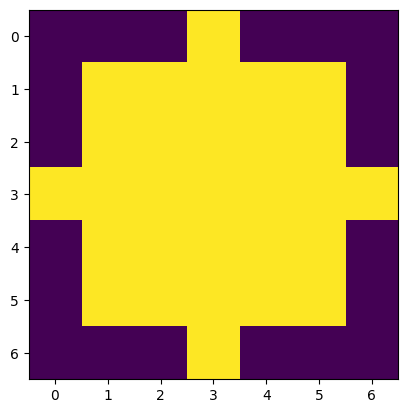

In [ ]:
plt.imshow(element)
plt.show()  

In [ ]:
closing(result, element)

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(303, 384))

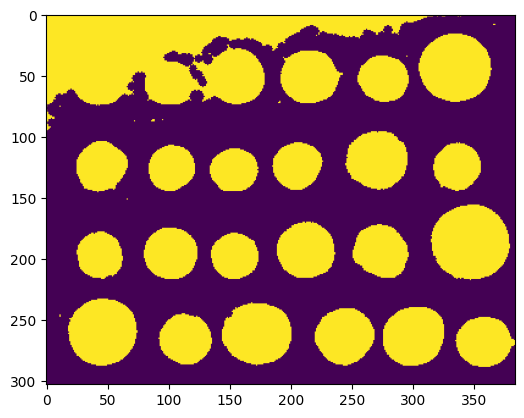

In [ ]:
plt.imshow(closing(result, element))
plt.show()  

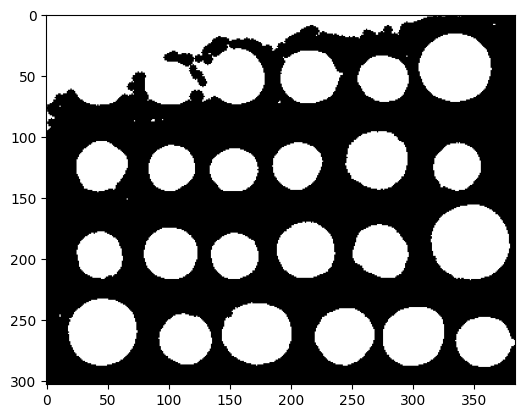

In [ ]:
plt.imshow(closing(result, element), cmap='gray')
plt.show()

In [ ]:
regionprops_table(result, properties=['area', 'perimeter', 'bbox', 'centroid'])

{'area': array([47145.]),
 'perimeter': array([4601.89898732]),
 'bbox-0': array([0]),
 'bbox-1': array([0]),
 'bbox-2': array([289]),
 'bbox-3': array([381]),
 'centroid-0': array([137.9328879]),
 'centroid-1': array([186.95119313])}

In [ ]:
label_image = label(result)

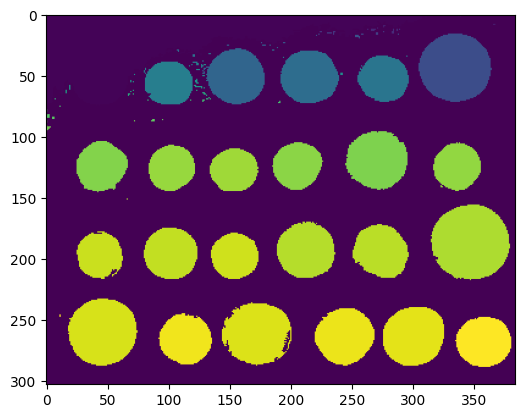

In [ ]:
plt.imshow(label_image)
plt.show()  

In [ ]:
regionprops_table(label_image, properties=['area', 'perimeter', 'bbox', 'centroid', 'eccentricity', 'extent', 'solidity'])

{'area': array([9.447e+03, 2.000e+00, 2.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        2.000e+00, 3.000e+00, 1.000e+00, 1.000e+00, 7.000e+00, 6.000e+00,
        2.000e+00, 1.000e+00, 2.000e+00, 4.000e+00, 1.000e+00, 4.000e+00,
        4.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 2.607e+03, 1.000e+00,
        8.000e+00, 1.000e+00, 2.000e+00, 2.000e+00, 3.000e+00, 1.000e+00,
        1.000e+00, 1.694e+03, 3.000e+00, 2.000e+00, 1.641e+03, 2.000e+00,
        4.000e+00, 1.235e+03, 1.000e+00, 1.000e+00, 1.000e+00, 1.141e+03,
        8.000e+00, 1.000e+00, 6.000e+00, 1.000e+00, 3.000e+00, 4.000e+00,
        1.000e+00, 2.000e+00, 7.000e+00, 2.000e+00, 1.000e+00, 4.000e+00,
        9.000e+00, 1.000e+00, 3.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        5.000e+00, 3.000e+00, 1.000e+00, 4.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 3.000e+00, 3.000e+00, 1.000e+00, 2.000e+00, 8.000e+00,
        4.000e+00, 5.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 1.100e+01,
        1.896e+03, 1.327e+03, 

In [ ]:
coin_properties = pd.DataFrame(regionprops_table(label_image, properties=['area', 'perimeter', 'bbox', 'centroid', 'eccentricity', 'extent', 'solidity']))

In [ ]:
coin_properties

,area,perimeter,bbox-0,bbox-1,bbox-2,bbox-3,centroid-0,centroid-1,eccentricity,extent,solidity
0,9447.0,944.487373,0,0,76,327,22.846512,95.440351,0.979528,0.380130,0.659246
1,2.0,0.000000,0,328,1,330,0.000000,328.500000,1.000000,1.000000,1.000000
2,2.0,0.000000,0,337,2,338,0.500000,337.000000,1.000000,1.000000,1.000000
3,3.0,3.414214,0,339,2,341,0.333333,339.333333,0.816497,0.750000,1.000000
4,1.0,0.000000,0,342,1,343,0.000000,342.000000,0.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
93,1966.0,163.296465,240,276,288,326,263.199898,300.655646,0.421994,0.819167,0.983000
94,1739.0,157.988853,241,220,288,269,263.373203,244.077056,0.330834,0.755102,0.973684
95,1388.0,141.539105,245,92,287,136,265.849424,113.771614,0.318618,0.751082,0.966574
96,2.0,0.000000,246,11,248,12,246.500000,11.000000,1.000000,1.000000,1.000000


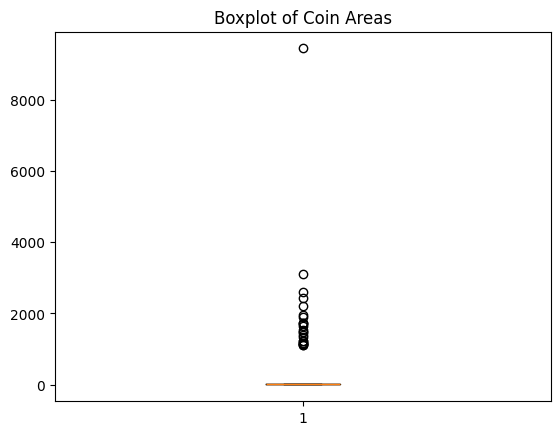

In [ ]:
plt.boxplot(coin_properties.area)
plt.title('Boxplot of Coin Areas')
plt.show()

In [ ]:
coin_properties.sort_values('area', ascending=False)

,area,perimeter,bbox-0,bbox-1,bbox-2,bbox-3,centroid-0,centroid-1,eccentricity,extent,solidity
0,9447.0,944.487373,0,0,76,327,22.846512,95.440351,0.979528,0.380130,0.659246
85,3113.0,213.894444,156,315,218,380,186.386765,347.137488,0.287262,0.772457,0.975556
22,2607.0,188.752309,16,305,72,365,43.447641,334.593786,0.327907,0.775893,0.981921
91,2439.0,184.923882,233,18,288,75,259.798278,45.920459,0.258981,0.777990,0.976772
92,2202.0,227.651804,236,144,288,201,261.019528,172.189827,0.416528,0.742915,0.937021
...,...,...,...,...,...,...,...,...,...,...,...
66,1.0,0.000000,70,118,71,119,70.000000,118.000000,0.000000,1.000000,1.000000
74,1.0,0.000000,86,95,87,96,86.000000,95.000000,0.000000,1.000000,1.000000
76,1.0,0.000000,87,72,88,73,87.000000,72.000000,0.000000,1.000000,1.000000
69,1.0,0.000000,75,11,76,12,75.000000,11.000000,0.000000,1.000000,1.000000


## Other operations on images

In [ ]:
model = LogisticRegression(C=1e10)

In [ ]:
sunset_image.ravel().shape

(1127250,)

In [57]:
np.corrcoef(tiger_image_eye_grey)

array([[ 1.        ,  0.92948142,  0.78637762, ...,  0.1678692 ,
         0.35405096,  0.10847724],
       [ 0.92948142,  1.        ,  0.90866981, ...,  0.28579177,
         0.32930308, -0.03717053],
       [ 0.78637762,  0.90866981,  1.        , ...,  0.26924881,
         0.15189467, -0.22612664],
       ...,
       [ 0.1678692 ,  0.28579177,  0.26924881, ...,  1.        ,
         0.63239715, -0.10961838],
       [ 0.35405096,  0.32930308,  0.15189467, ...,  0.63239715,
         1.        ,  0.61942948],
       [ 0.10847724, -0.03717053, -0.22612664, ..., -0.10961838,
         0.61942948,  1.        ]], shape=(50, 50))

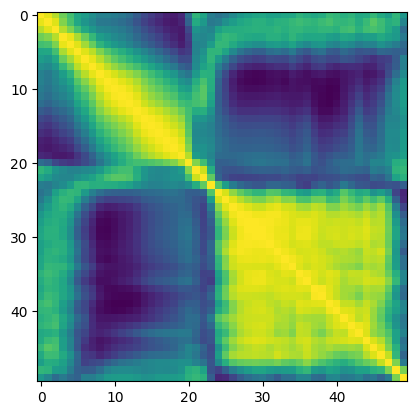

In [59]:
plt.imshow(np.corrcoef(tiger_image_eye_grey))
plt.show()  

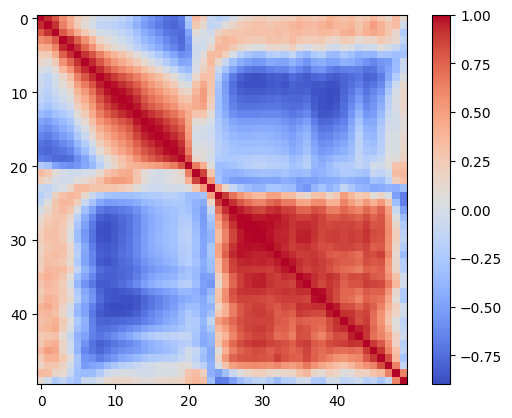

In [61]:
plt.imshow(np.corrcoef(tiger_image_eye_grey), cmap='coolwarm')
plt.colorbar()  
plt.show()

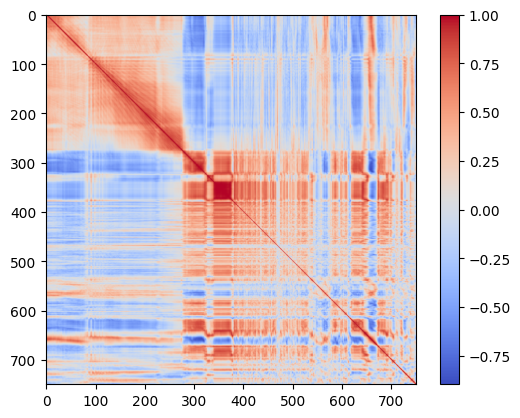

In [64]:
plt.imshow(np.corrcoef(sunset_image[:, :, 0]), cmap='coolwarm')
plt.colorbar()
plt.show()

In [66]:
pca = PCA(n_components=30)


In [73]:
sunset_image.ravel().reshape(-1, 3).shape

(375750, 3)

In [75]:
pca.fit(np.corrcoef(sunset_image[:, :, 0]))

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",30
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [77]:
pca.transform(np.corrcoef(sunset_image[:, :, 0])).shape

(750, 30)

In [94]:
faces = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\PC\scikit_learn_data


In [95]:
images = faces['data']

In [96]:
images.shape

(400, 4096)

In [98]:
images = faces['images']
images.shape
images[0].shape

(64, 64)

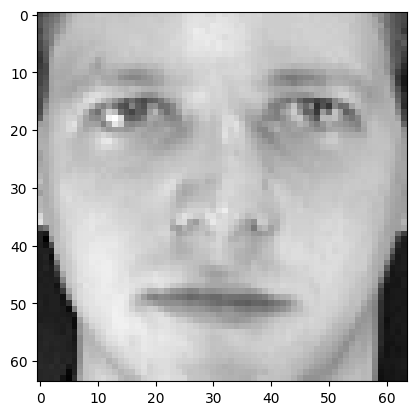

In [99]:
plt.imshow(images[0], cmap='gray')

In [100]:
classes = faces['target']

In [101]:
classes

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

In [102]:
images = images.reshape(400, -1)


In [103]:
images.shape

(400, 4096)

In [104]:
pca = PCA(n_components=50)

In [105]:
pca.fit(images)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [106]:
np.cumsum(pca.explained_variance_ratio_)

array([0.23812726, 0.37806672, 0.4577528 , 0.5077361 , 0.54383457,
       0.5754039 , 0.59967226, 0.62003624, 0.6396174 , 0.6563386 ,
       0.6722908 , 0.6866606 , 0.699128  , 0.7105993 , 0.72122806,
       0.73100525, 0.7401959 , 0.7483516 , 0.7558903 , 0.76336014,
       0.7703459 , 0.7764922 , 0.7823314 , 0.78802854, 0.7934904 ,
       0.7988088 , 0.8039469 , 0.80890524, 0.81348175, 0.81789345,
       0.8219124 , 0.8257539 , 0.8293722 , 0.832715  , 0.83591264,
       0.8390694 , 0.8421131 , 0.8450974 , 0.8479101 , 0.85064334,
       0.85323876, 0.8557598 , 0.85819083, 0.8605709 , 0.8628547 ,
       0.8650761 , 0.8672733 , 0.86941695, 0.8714295 , 0.8734183 ],
      dtype=float32)

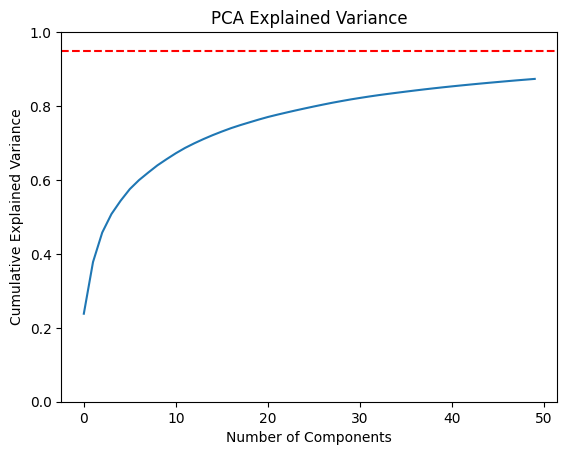

In [109]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.ylim(0, 1)
plt.axhline(y=0.95, color='red', linestyle='--')
plt.show()

In [110]:
pca = PCA(n_components=100)

In [112]:
pca.fit(images)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",100
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

In [113]:
np.cumsum(pca.explained_variance_ratio_)

array([0.2381271 , 0.3780667 , 0.45775288, 0.5077362 , 0.5438347 ,
       0.57540405, 0.5996724 , 0.62003636, 0.6396175 , 0.6563387 ,
       0.6722909 , 0.6866607 , 0.6991281 , 0.7105994 , 0.7212282 ,
       0.7310054 , 0.740196  , 0.74835175, 0.7558905 , 0.7633603 ,
       0.7703461 , 0.7764924 , 0.7823317 , 0.78802896, 0.7934909 ,
       0.79880947, 0.8039476 , 0.808906  , 0.81348264, 0.81789446,
       0.8219145 , 0.8257564 , 0.82937586, 0.8327213 , 0.8359251 ,
       0.8390855 , 0.842137  , 0.84512335, 0.84794474, 0.8506848 ,
       0.8532825 , 0.8558224 , 0.85826784, 0.8606662 , 0.8629751 ,
       0.86523926, 0.8674621 , 0.8696665 , 0.8717557 , 0.8738055 ,
       0.87577385, 0.87768793, 0.87953836, 0.8813274 , 0.88310325,
       0.8848278 , 0.8865135 , 0.88815445, 0.8897729 , 0.8913565 ,
       0.8929105 , 0.8944325 , 0.8959317 , 0.89740855, 0.8988341 ,
       0.9002395 , 0.9016082 , 0.90294546, 0.90425354, 0.9055385 ,
       0.90681124, 0.9080714 , 0.9093048 , 0.91051465, 0.91169

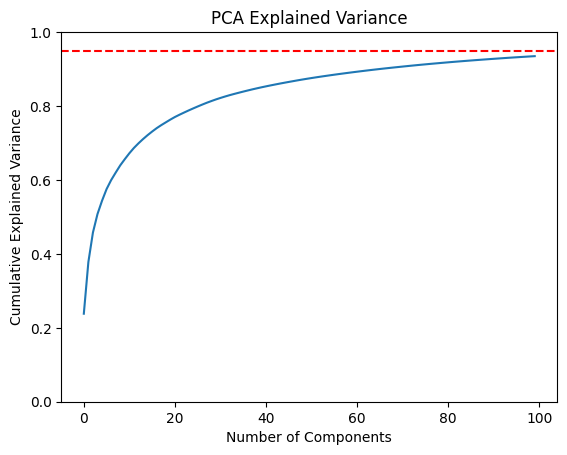

In [114]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.ylim(0, 1)
plt.axhline(y=0.95, color='red', linestyle='--')
plt.show()

In [116]:
pca.n_components_

100

In [117]:
100/4096

0.0244140625

In [119]:
images_transform = pca.transform(images).shape

In [120]:
np.linalg.norm(images_transform[0] - images_transform[1])

np.float64(300.0)